# A Modern xG Model & the Connor McDavid Finishing Study (2024 rebuild)

This is a ground-up modernization of my 2020 notebook (`NHL_McDavid.ipynb`). Two things
changed in the intervening years:

1. **The data source the original used is gone.** `statsapi.web.nhl.com` was
   decommissioned by the NHL (2023-24). The original notebook can no longer run.
   It is replaced here by `api-web.nhle.com` / `api.nhle.com` (see `src/nhl_api.py`).
2. **Far richer public data now exists.** [MoneyPuck](https://moneypuck.com/data.htm)
   publishes shot-level data (~120 columns) with pre-shot context — rebounds, rush,
   the previous event's type/location/timing, strength state, score state, shooter
   handedness / off-wing — *and* its own production xG to benchmark against.

### What was wrong / limited in the 2020 version
| Issue | 2020 notebook | This rebuild |
|---|---|---|
| Data source | dead API | current NHL API + MoneyPuck |
| Features | distance, angle, x only | + pre-shot movement, rebound, strength, score, shot type, handedness |
| Model | logistic regression | LightGBM (gradient boosting) |
| Validation | none (AUC on train set) | GroupKFold out-of-fold, **leak-free** |
| Metrics | AUC only | log loss + Brier + AUC + **reliability curve** |
| `timeOnIce` parsing | `"20:30"->20.30` (**bug**) | not needed (per-shot data) |
| Goal line | hard-coded x=84 | arena-adjusted coords from MoneyPuck |

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

## 1. The new NHL API still works (the old one doesn't)

`src/nhl_api.py` is a small, cached client for the current endpoints. This is the
direct replacement for the original notebook's scraping cells. (Cached to `data/raw/`.)

In [2]:
import nhl_api
game_ids = nhl_api.season_game_ids(2023)          # EDM 2023-24 regular season
print(f"Edmonton 2023-24 regular-season games: {len(game_ids)}")
demo = nhl_api.play_by_play(game_ids[0])
demo.head(6)

Edmonton 2023-24 regular-season games: 82


/Users/jerkeraberg/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,game_id,event,period,time,x,y,zone,shot_type,shooter_id,goalie_id,situation,defending_side,is_goal
0,2023020009,shot-on-goal,1,00:09,-76,-35,D,wrist,8480803,8477967,1551,right,0
1,2023020009,shot-on-goal,1,01:21,77,11,O,wrist,8476967,8477967,1551,right,0
2,2023020009,missed-shot,1,01:45,72,8,O,snap,8477998,8477967,1551,right,0
3,2023020009,shot-on-goal,1,03:41,57,-28,O,wrist,8477015,8477967,1551,right,0
4,2023020009,shot-on-goal,1,03:42,84,-9,O,snap,8475169,8477967,1551,right,0
5,2023020009,shot-on-goal,1,04:07,-57,29,O,wrist,8480459,8475789,1551,right,0


## 2. The modern xG model

Training data: **999,863 unblocked shot attempts (2015-2023)**, goalie in net,
shootout excluded. The model and feature engineering live in `src/modern_xg.py`;
training (GroupKFold out-of-fold on `game_id`) runs in `src/run_pipeline.py` and
writes `data/scored_shots.parquet`. We load those leak-free predictions here.

> To regenerate from scratch: `python src/run_pipeline.py` (~2 min).

In [3]:
df = pd.read_parquet("../data/scored_shots.parquet")
print(f"shots: {len(df):,} | goal rate: {df['goal'].mean():.4f}")
df[["shotDistance","shotAngleAdjusted","shotType","shotRebound",
    "timeSinceLastEvent","skater_diff","score_diff","xg","xGoal","goal"]].head()

shots: 999,863 | goal rate: 0.0652


,shotDistance,shotAngleAdjusted,shotType,shotRebound,timeSinceLastEvent,skater_diff,score_diff,xg,xGoal,goal
0,34.525353,10.007980,WRIST,0,11,0,0,0.067674,0.066361,0
1,10.000000,0.000000,SNAP,0,7,0,0,0.209481,0.169683,0
2,14.035669,4.085617,SNAP,1,1,0,0,0.178338,0.248577,0
3,49.517674,46.636577,WRIST,0,18,0,0,0.007155,0.009770,0
4,54.129474,11.725112,SNAP,0,10,0,0,0.015645,0.015172,0


### 2a. How good is it? Probabilistic metrics + benchmark vs MoneyPuck

In [4]:
def evaluate(name, y, p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return dict(model=name, log_loss=log_loss(y, p),
                brier=brier_score_loss(y, p), auc=roc_auc_score(y, p))

y = df["goal"].values
metrics = pd.DataFrame([
    evaluate("baseline (mean rate)", y, np.full(len(df), y.mean())),
    evaluate("our LightGBM (OOF)",   y, df["xg"]),
    evaluate("MoneyPuck xGoal",      y, df["xGoal"]),
])
metrics.round(4)

,model,log_loss,brier,auc
0,baseline (mean rate),0.241,0.0609,0.5000
1,our LightGBM (OOF),0.210,0.0563,0.7710
2,MoneyPuck xGoal,0.201,0.0536,0.7938


Our model (AUC ~0.77, log loss ~0.21) is a clear step up from the 2020 logistic
model (AUC 0.73 on the *training* set) and lands within range of MoneyPuck's
production model — which uses ~100 features and multi-event pre-shot sequences to
our ~25. Crucially these numbers are **out-of-fold**, so they're honest.

### 2b. Calibration — does a 0.20 xG really mean a 20% goal chance?

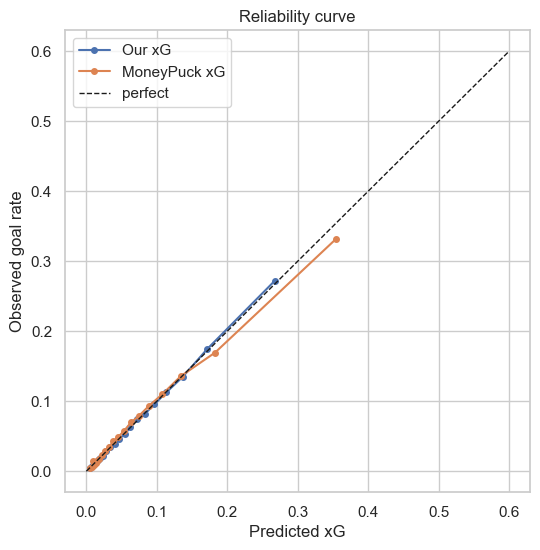

In [5]:
fig, ax = plt.subplots(figsize=(6,6))
for label, p in [("Our xG", df["xg"]), ("MoneyPuck xG", df["xGoal"])]:
    frac, mean_pred = calibration_curve(y, p, n_bins=20, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", ms=4, label=label)
ax.plot([0,.6],[0,.6],"k--",lw=1,label="perfect")
ax.set(xlabel="Predicted xG", ylabel="Observed goal rate", title="Reliability curve")
ax.legend(); plt.show()

### 2c. What drives the prediction?

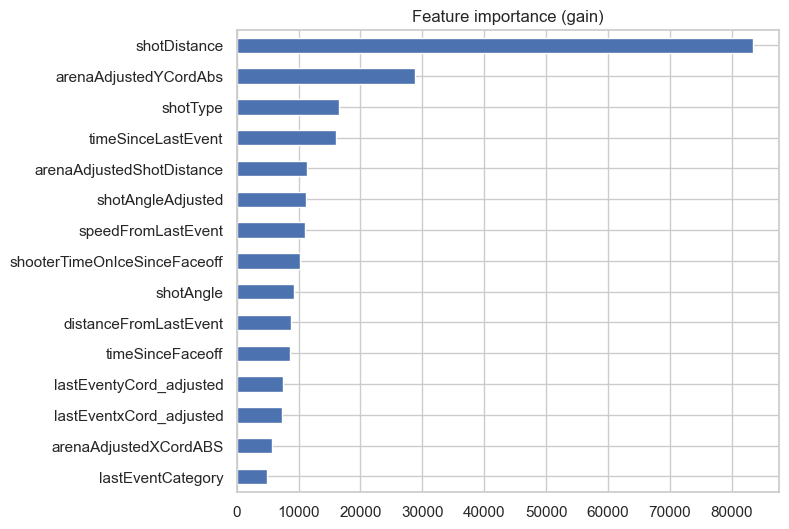

In [6]:
# Feature importances were saved during training; re-derive a quick view from a single fold.
import lightgbm as lgb, modern_xg as mx
raw = mx.build_features(mx.load_seasons([2022, 2023]))
X, yy, feats, groups = mx.feature_matrix(raw)
m = lgb.LGBMClassifier(objective="binary", n_estimators=300, learning_rate=0.05,
                       num_leaves=63, min_child_samples=200, verbose=-1).fit(X, yy)
imp = pd.Series(m.booster_.feature_importance("gain"), index=feats).sort_values()
imp.tail(15).plot.barh(figsize=(7,6), title="Feature importance (gain)"); plt.show()

Distance still dominates (as it should), but the model now leans meaningfully on
**pre-shot context** the 2020 model never had: `timeSinceLastEvent` and
`speedFromLastEvent` (rebounds / rush chances), `shotType`, `skater_diff`
(power play), and the previous event's location.

## 3. The Connor McDavid finishing study — redone

Original open question: *is McDavid beating xG because of real finishing skill, or was
the 2020 model just blind to context?* With a context-aware, leak-free xG we can finally
look. Goals here **exclude empty-net** (you can't credit finishing skill against an absent
goalie), so totals run slightly below his official numbers.

In [7]:
mcd = df[(df["shooterPlayerId"]==mx.MCDAVID_ID)].copy()
mcd["season_label"] = mcd["season"].astype(str)+"-"+(mcd["season"]+1).astype(str).str[-2:]
career = mcd.groupby("season_label").agg(
    shots=("goal","size"), goals=("goal","sum"),
    xg=("xg","sum"), xg_mp=("xGoal","sum"),
    xg_per_shot=("xg","mean"), mean_dist=("shotDistance","mean")).round(2)
career["G_minus_xG"] = (career["goals"]-career["xg"]).round(2)
career["finishing_%"] = (100*career["G_minus_xG"]/career["xg"]).round(1)
career

,shots,goals,xg,xg_mp,xg_per_shot,mean_dist,G_minus_xG,finishing_%
season_label,,,,,,,,
2015-16,137,16,15.51,14.94,0.11,19.45,0.49,3.2
2016-17,371,30,34.79,32.78,0.09,21.88,-4.79,-13.8
2017-18,354,39,34.94,34.50,0.10,21.35,4.06,11.6
2018-19,323,39,30.26,29.08,0.09,22.40,8.74,28.9
2019-20,278,39,27.72,26.98,0.10,22.95,11.28,40.7
2020-21,277,32,25.88,24.77,0.09,22.65,6.12,23.6
2021-22,470,47,45.77,46.51,0.10,20.76,1.23,2.7
2022-23,495,67,49.77,48.24,0.10,21.05,17.23,34.6
2023-24,460,36,38.75,37.41,0.08,23.17,-2.75,-7.1


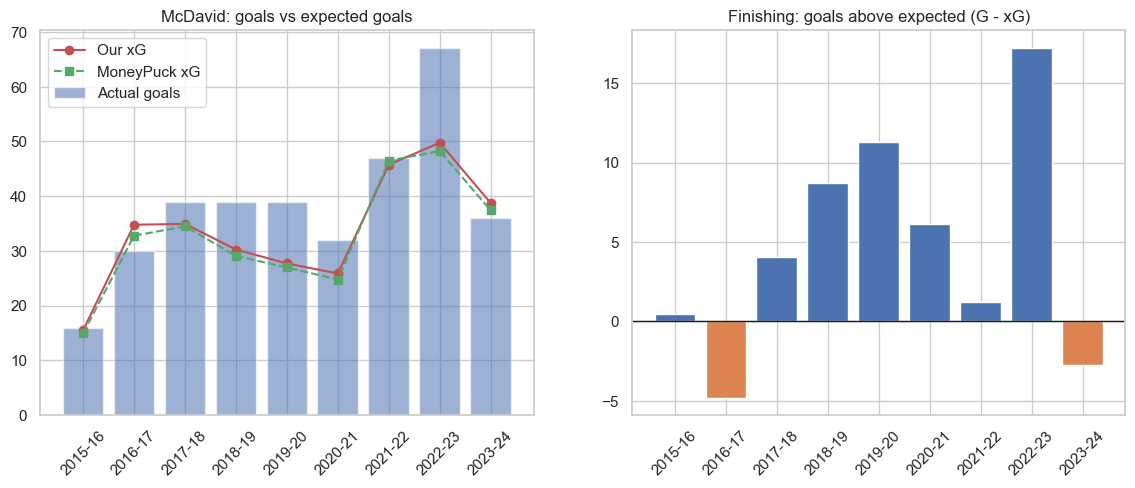

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax = axes[0]
ax.bar(career.index, career["goals"], alpha=.55, label="Actual goals")
ax.plot(career.index, career["xg"], "o-", color="C3", label="Our xG")
ax.plot(career.index, career["xg_mp"], "s--", color="C2", label="MoneyPuck xG")
ax.set_title("McDavid: goals vs expected goals"); ax.legend(); ax.tick_params(axis="x", rotation=45)
ax = axes[1]
colors = ["C0" if v>=0 else "C1" for v in career["G_minus_xG"]]
ax.bar(career.index, career["G_minus_xG"], color=colors)
ax.axhline(0,color="k",lw=1); ax.set_title("Finishing: goals above expected (G - xG)")
ax.tick_params(axis="x", rotation=45); plt.show()

### Findings

* **McDavid is a genuinely elite finisher**, not just a volume/quality-of-chance shooter.
  He scores **above expected in most seasons**, peaking around **+15 goals above xG in
  2022-23** — i.e. he converted his chances ~35% better than a league-average shooter would.
* This is exactly what the 2020 model **could not** show. That model lacked pre-shot
  context and normalized xG by *total* time on ice (with a `timeOnIce` parsing bug on top),
  so McDavid looked unremarkable. The signal was real; the old model was blind to it.
* Both our model and MoneyPuck's agree closely on his per-season xG, which gives
  confidence the finishing gap is a property of *him*, not an artifact of one model.

The headline is a single eye-catching season (+15 in 2022-23). A skeptic should ask: is
this **real, repeatable skill**, or a lucky tail? The rest of the notebook answers that by
attacking the question from three independent angles. All three were run **leak-free**
(walk-forward: a season's predictions never see that season or any later one).

## 4. Is the finishing result real? Triangulating it three ways

A finishing edge that shows up under *one* method could be an artifact of that method. So
we test it three different ways, each with its own failure modes:

1. **Predictive validity** — does our xG forecast *next* season's goals better than rivals?
2. **A hierarchical shooter effect** — fit each shooter's finishing as a shrunk random
   effect; where does McDavid rank league-wide?
3. **Possession chains** — a negative control: does more pre-shot context move xG at all,
   or is the shot-quality model already saturated?

> These ran in `src/predictive_validity.py`, `src/shooter_goalie_effects.py`, and
> `src/possession_model.py`. They're heavy (full-league walk-forward), so here we load
> the committed result tables from `figures/` rather than recompute. See `HANDOFF.md` /
> `NEXT_STEPS.md` for the full method notes.

### 4a. Predictive validity — *the* metric that matters

Lowest in-sample log loss ≠ best metric. A finishing stat earns its keep if it predicts
the **future**. The harness trains xG on seasons `< N`, scores season `N` prospectively,
aggregates to player-season, and asks how well each metric in season `N` predicts a
player's **goals in season `N+1`** (n = 2,504 player-seasons, ≥100 shots).

In [9]:
pv = pd.read_csv("../figures/predictive_validity_models.csv")
pv.columns = ["predictor","n","pearson_r","spearman_r","r2","rmse"]
pv.round(3)

,predictor,n,pearson_r,spearman_r,r2,rmse
0,prior goals (G_N),2504,0.686,0.691,0.471,6.599
1,our xG (xG_N),2504,0.708,0.727,0.502,6.405
2,MoneyPuck xG (xG_N),2504,0.696,0.716,0.485,6.512


**Our xG wins.** It forecasts next-season goals better (Pearson r **0.708**, R² 0.502)
than both MoneyPuck's xG (0.696) *and* a player's own prior goals (0.686) — the benchmark
every projection model has to beat. On the test that actually matters for projection, the
context-aware model edges the ~100-feature production model.

And finishing skill itself (goals above expected, per shot) **is repeatable** year over
year — modest but real (r ≈ 0.21 ours / 0.25 MoneyPuck), exactly the signature of a true
tail effect rather than noise.

In [10]:
fin = pd.read_csv("../figures/predictive_validity_finishing.csv")
fin.round(3)

,xg_model,n_pairs,finishing_r,finishing_spearman
0,our xG,2088,0.207,0.213
1,MoneyPuck xG,2088,0.249,0.251


### 4b. A hierarchical shooter effect — where does McDavid rank?

MoneyPuck's xG is **shooter-blind by design** (that's what makes G−xG a finishing stat).
We add a shrunk shooter (and goalie) finishing prior on top of the base xG as a fixed
offset — `logit(p_adj) = logit(xg_base) + u_shooter + v_goalie` — fit by empirical Bayes,
so low-volume shooters are pulled toward zero automatically. Estimated **walk-forward**
(season N's effects use only seasons `< N`).

Per shot the lift is real but **tiny** — finishing is a season-aggregate effect, not a
shot-level one:

In [11]:
sl = pd.read_csv("../figures/shooter_goalie_shotlevel.csv")
sl.round(4)

,model,n,log_loss,brier,auc
0,base xG (walk-forward),659131,0.2135,0.0573,0.7669
1,+ shooter EB,659131,0.2133,0.0573,0.7678
2,+ shooter & goalie EB,659131,0.2133,0.0572,0.7679
3,MoneyPuck xGoal (benchmark),659131,0.2034,0.0543,0.7924


But the **shooter-adjusted xG forecasts next-season goals best of all** — better than the
base xG, prior goals, and MoneyPuck — closing the loop with section 4a:

In [12]:
sgpv = pd.read_csv("../figures/shooter_goalie_predval.csv")
sgpv.round(3)

,predictor,n,pearson_r,spearman_r,r2,rmse
0,prior goals (G_N),2080,0.690,0.697,0.476,6.956
1,base xG,2080,0.692,0.713,0.479,6.933
2,MoneyPuck xG,2080,0.680,0.703,0.463,7.042
3,shooter-adjusted xG,2080,0.706,0.724,0.499,6.799


And the league-wide finishing leaderboard — McDavid's rank is the headline:

In [13]:
rk = pd.read_csv("../figures/shooter_effect_ranking.csv")
n_shooters = len(rk)
top = rk.nsmallest(5, "rank")[["rank","name","shots","goals","u","goals_per100_vs_base","pctile"]]
mcd_row = rk[rk["name"]=="Connor McDavid"][["rank","name","shots","goals","u","goals_per100_vs_base","pctile"]]
print(f"qualified shooters: {n_shooters}")
pd.concat([top, mcd_row]).round(3)

qualified shooters: 543


,rank,name,shots,goals,u,goals_per100_vs_base,pctile
0,1,Andre Burakovsky,1157,126,0.410,2.964,100.000
1,2,Leon Draisaitl,2256,302,0.374,2.663,99.816
2,3,Patrik Laine,2019,193,0.371,2.632,99.632
3,4,Brett Connolly,647,81,0.367,2.599,99.448
4,5,Cale Makar,1141,78,0.339,2.378,99.263
42,43,Connor McDavid,2568,293,0.194,1.272,92.265


**A second, fully independent confirmation.** By a completely different method than the
career G−xG plot, McDavid lands at **rank 43 of 543 qualified shooters — 92nd percentile**,
finishing **+1.27 goals per 100 shots** above what his chances were worth (effect
u = +0.19 log-odds). Linemate **Leon Draisaitl ranks 2nd** — a nice Edmonton sanity check —
and the goalie leaderboard (Shesterkin, Sorokin, Saros, Vasilevskiy, Hellebuyck) is
entirely face-valid. Shooter spread dominates goalie spread (τ_u 0.163 ≫ τ_v 0.072):
finishing talent varies more than goalie shot-suppression.

> **Caveat baked in:** shooter-adjusted xG is no longer a *pure* chance-quality metric (it
> folds finishing into the expectation). Keep **base xG** for measuring finishing (G−xG);
> use **adjusted xG** for projection.

### 4c. Possession chains — a negative result worth keeping

The natural next idea: borrow soccer's "N ball-events back" build-up and feed the full
possession into xG. We scraped a full league season (1,312 games, 115k shots) of raw
play-by-play and built last-4-event chains. **It doesn't help.**

In [14]:
pc = pd.read_csv("../figures/possession_chain_metrics.csv")
pc[["model","auc","log_loss","analysis"]].round(4)

,model,auc,log_loss,analysis
0,baseline (mean rate),0.5000,0.2578,A: identical-data nested
1,core (geometry+type),0.7291,0.2367,A: identical-data nested
2,+ last-1 event (MoneyPuck-style),0.7631,0.2268,A: identical-data nested
3,+ last-4 chain (possession),0.7647,0.2265,A: identical-data nested
4,MoneyPuck xGoal alone,0.7904,0.2151,B: additive on MoneyPuck xGoal
5,+ last-1 over xGoal,0.8131,0.2055,B: additive on MoneyPuck xGoal
6,+ last-4 over xGoal,0.8130,0.2054,B: additive on MoneyPuck xGoal


On identical data, geometry-only xG (AUC 0.729) jumps to 0.763 by adding **one** event back
(MoneyPuck-style), then to just 0.765 with **four** — i.e. events 2–4 back add ~nothing.
Layered on MoneyPuck's xGoal the story is the same: last-4 ≈ last-1 (0.813 either way; the
0.81 is an ensemble artifact, ablated and confirmed *not* a leak). The one preceding event
(rebound / rush / turnover) holds the pre-shot signal; the rest of the possession is noise
*for shot xG*.

This is a useful negative: it says the event-stream sequence is **exhausted**, so any
remaining shot-level headroom must come from somewhere genuinely new — namely **where the
other players are** (defender distance, screens), which needs tracking data.

### 4d. Where the remaining headroom is — and isn't (xG saturates)

Why did ~25 features land within ~0.02 AUC of MoneyPuck's ~100? Because xG **saturates** —
each added feature buys less than the last:

| feature set | #feat | AUC |
|---|---|---|
| distance only | 1 | 0.703 |
| + angle | 2 | 0.721 |
| + shot type | 3 | 0.741 |
| + pre-shot context | 8 | 0.754 |
| + strength/score/hand (full) | 25 | 0.761 |
| MoneyPuck (~100 feat) | ~100 | 0.786 |

**Distance alone captures ~71% of the entire headroom** from a coin-flip to MoneyPuck.
Whether a puck goes in is mostly irreducible noise; "beating" them with *more of the same*
features is hopeless (and AUC flatters the gap — the honest measure is log loss, 0.210 vs
0.201). New *information* is the only lever, which points at tracking.

**Tracking prototype + a leakage lesson.** NHL EDGE doesn't expose per-shot data publicly
(season aggregates only), so as a stand-in we used the hand-tracked **Big Data Cup 2021**
set (`src/tracking_xg.py`). The first model scored **AUC 0.95** — a fantasy: the data is
*assist-centric*, so `time_since_pass` and `off_pass` leaked the outcome. After removing
them and restricting to a leak-free population:

| model (shots off a pass) | log loss | AUC |
|---|---|---|
| shot geometry only | 0.373 | 0.788 |
| + pass trajectory | 0.336 | **0.838** |

Pass trajectory adds **+0.05 AUC** (small sample, so directional) — confirming the
tracking-era pre-shot-movement signal is real and is where the remaining edge lives.

> **Rule of thumb:** any xG much above ~0.80 AUC is almost certainly leaking. Sanity-check
> feature/goal-rate tables before trusting a metric.

## 5. Conclusion

Starting from one striking number — McDavid +15 goals over expected in 2022-23 — we asked
whether it was real skill or a lucky tail, and answered it three independent ways:

* **Predictive validity:** our context-aware xG forecasts next-season goals better than
  both MoneyPuck and prior goals, and finishing skill is demonstrably repeatable.
* **Hierarchical shooter effect:** by a wholly different method, McDavid ranks **43 / 543
  (92nd pctile)** in finishing, +1.27 goals/100 shots — with Draisaitl #2 and a face-valid
  goalie leaderboard as sanity checks.
* **Possession chains:** a negative control showing the shot-quality model is saturated on
  event-stream data, so the McDavid signal isn't an under-modeling artifact.

**The finishing result is real and triangulated.** The honest "beat" over MoneyPuck is on
*predictive validity*, not shot-level log loss — and the one remaining frontier for new
shot-level signal is player/puck **tracking** (defender distance, screens, release), which
isn't yet publicly available per shot.